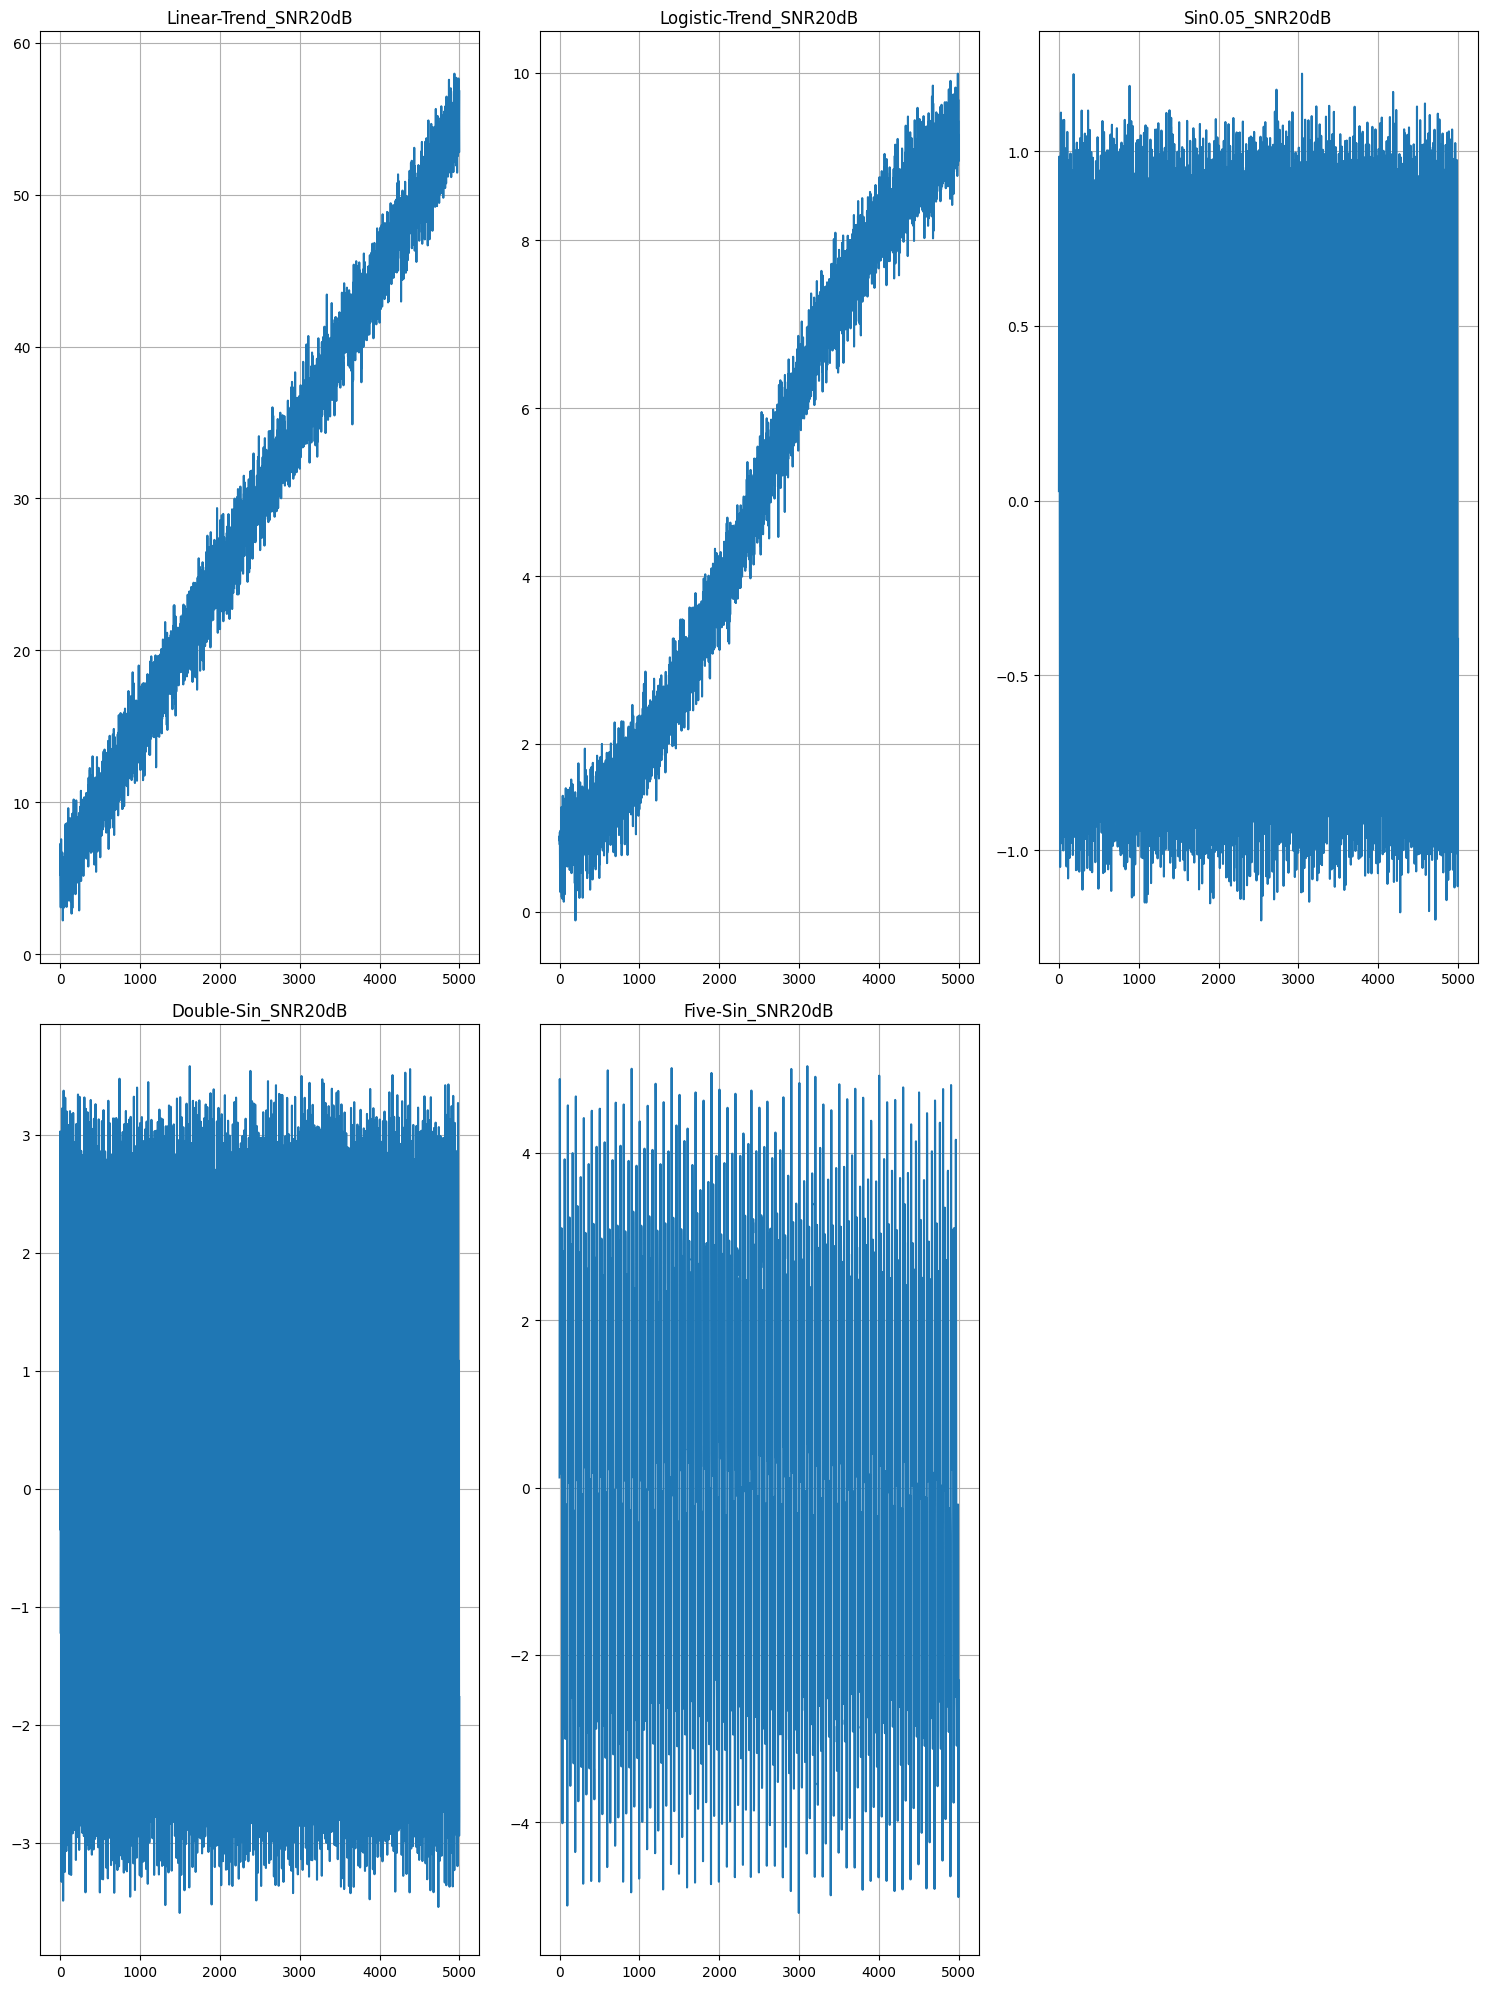


==== Generating datasets with 0.5% anomalies ====

Generating point anomalies for Linear-Trend with ratio 0.005


TypeError: add_point_anomalies() got an unexpected keyword argument 'debug'

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from statsmodels.tsa.arima_process import ArmaProcess
import pandas as pd

# Shared helper functions for signal generation/noise utilities
try:
    from dataset.signal_generators import *
except ModuleNotFoundError:
    from signal_generators import *

# Main program
def generate_and_save_datasets(seed, dataset_folder, dataset_id):
    n = 5000  # Signal length
    np.random.seed(seed)  # Set random seed
    
    # Define signal generators
    signal_generators = {
        "Linear-Trend": lambda: generate_linear_signal(n, slope=0.01, intercept=5),
        "Logistic-Trend": lambda: generate_logistic_signal(n, L=10, k=0.001),
        "Sin0.05": lambda: generate_sine_wave(n, amplitude=1, frequency=0.05),
        "Double-Sin": lambda: generate_composite_sine(n, [(2, 0.1, 0), (1.5, 0.05, 0)]),
        "Five-Sin": lambda: generate_composite_sine(n, [
            (1, 0.01, 0), (1.2, 0.02, 0), (2, 0.05, 0),(1.4, 0.08, 0), (0.9, 0.1, 0)
        ]),
    }

    # 1. Generate datasets with different SNR noise
    snr_db_values = [20]  # Define SNR range (in dB)
    for snr_db in snr_db_values:
        for signal_name, generator in signal_generators.items():
            signal_data = generator()
            noisy_signal = add_noise_by_snr(signal_data, snr_db=snr_db)
            save_signal(noisy_signal, dataset_folder, signal_name, dataset_id=dataset_id, 
                       category=f"SNR{snr_db}dB", length=n)
        
        # Visualize noisy signals (optional)
        plot_signals({f"{signal_name}_SNR{snr_db}dB": add_noise_by_snr(generator(), snr_db)
                      for signal_name, generator in signal_generators.items()})

    # 2. Point anomalies - using different ratios of anomalous points
    anomaly_ratios = [0.005, 0.01, 0.05, 0.10, 0.15, 0.20]
    
    for anomaly_ratio in anomaly_ratios:
        print(f"\n==== Generating datasets with {anomaly_ratio*100}% anomalies ====")
        for signal_name, generator in signal_generators.items():
            signal_data = generator()
            # First add 20dB noise
            noisy_signal = add_noise_by_snr(signal_data, snr_db=20)
            # Then add point anomalies
            print(f"\nGenerating point anomalies for {signal_name} with ratio {anomaly_ratio}")
            anomalous_signal = add_point_anomalies(noisy_signal, 
                                                anomaly_ratio=anomaly_ratio,
                                                base_amplitude_range=(1, 2),
                                                debug=True)
            save_signal(anomalous_signal, dataset_folder, signal_name, dataset_id=dataset_id, 
                      category=f"point-anomaly-{int(anomaly_ratio*100)}pct", length=n)
        
        # Visualize point anomaly data with different ratios
        plot_signals({f"{signal_name}_point-anomaly-{int(anomaly_ratio*100)}pct": 
                    add_point_anomalies(add_noise_by_snr(generator(), 20), anomaly_ratio=anomaly_ratio)
                    for signal_name, generator in signal_generators.items()})
                    
    # 3. Pulse anomalies - using different numbers of pulses
    pulse_counts = [1, 3, 5, 10, 20]
    
    for pulse_count in pulse_counts:
        print(f"\n==== Generating datasets with {pulse_count} pulse anomalies ====")
        for signal_name, generator in signal_generators.items():
            signal_data = generator()
            # First add 20dB noise
            noisy_signal = add_noise_by_snr(signal_data, snr_db=20)
            # Then add pulse anomalies
            print(f"\nGenerating {pulse_count} pulse anomalies for {signal_name}")
            anomalous_signal = add_pulse_anomalies(noisy_signal,
                                                 num_pulses=pulse_count,
                                                 pulse_width_range=(10, 30),
                                                 base_amplitude_range=(1, 2),
                                                 debug=True)
            save_signal(anomalous_signal, dataset_folder, signal_name, dataset_id=dataset_id, 
                       category=f"pulse-anomaly-{pulse_count}", length=n)
        
        # Visualize pulse anomaly data with different pulse counts
        plot_signals({f"{signal_name}_pulse-anomaly-{pulse_count}": 
                    add_pulse_anomalies(add_noise_by_snr(generator(), 20), num_pulses=pulse_count)
                    for signal_name, generator in signal_generators.items()})

def generate_multiple_datasets(num_datasets=5):
    output_folder = "Dataset_generated_anomaly"  
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    for i in range(num_datasets):
        seed = i
        generate_and_save_datasets(seed, output_folder, i+1)

if __name__ == "__main__":
    generate_multiple_datasets(num_datasets=1)